# Computer Exercise 15.9 — Problem 1
## Tabular Q-learning (Off-Policy TD Control) 베이스라인

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.9 *Off-Policy Value-Based Deep RL* 도입부  
> **날짜**: 2026-07-24  
> **언어**: 한국어 (코드 주석 포함), 그래프 라벨은 영문

## 1. 문제 (원문)

> **Off-policy TD control (Q-learning).** Implement one-step Q-learning on the 4×4 deterministic GridWorld used in Day 75. The behaviour policy is $\varepsilon$-greedy with a small $\varepsilon>0$ (for exploration), while the *target* policy is the greedy policy $\pi^\star(s)=\arg\max_a Q(s,a)$. Study how the learned action-value estimate $Q(s,a)$ converges to the optimal $Q^\star$, how the greedy policy derived from $Q$ improves over episodes, and how the step-size $\alpha$ and exploration rate $\varepsilon$ interact.

### 한국어 풀이용 정리
- **환경**: 4×4 결정적 GridWorld — 시작 $(0,0)$, 목표 $(3,3)$, 매 스텝 -1, 목표 도달 후 0.
- **알고리즘**: 1-step Q-learning (Watkins, 1989),  
  $$Q(s,a)\leftarrow Q(s,a)+\alpha\bigl[r+\gamma\max_{a'} Q(s',a')-Q(s,a)\bigr].$$
- **관찰 요소**: (i) $Q$-error $\|Q-Q^\star\|_\infty$ 감쇠 곡선, (ii) 에피소드 리턴 학습곡선, (iii) $(\alpha,\varepsilon)$ 격자 위의 최종 성능 히트맵.

## 2. 수학적 배경

**Bellman 최적 방정식** (결정적 환경, 할인율 $\gamma$):
$$Q^\star(s,a)=r(s,a)+\gamma\,\max_{a'} Q^\star(s',a').$$

Q-learning 은 위 방정식의 *sample-based fixed-point iteration* 이다. 상태-행동 쌍 $(s,a,r,s')$ 을 어떤 정책으로 뽑든 (behaviour) 상관없이, 업데이트 자체는 target 정책 $\pi^\star = \arg\max_a Q$ 에 대응한다. 그래서 **off-policy** 라 부른다.

**수렴 조건 (Robbins–Monro)**: 각 $(s,a)$ 가 무한히 자주 방문되고 스텝사이즈가 $\sum_t \alpha_t=\infty,\;\sum_t \alpha_t^2<\infty$ 이면 확률 1 로 $Q\to Q^\star$ (tabular, deterministic, bounded reward). 상수 $\alpha$ 는 이론적 수렴 대신 $O(\alpha)$ 크기의 잡음 볼 안에서 진동한다.

**최적 리턴 (본 환경, $\gamma=0.99$)**: 상태 $s$ 에서 목표까지 Manhattan 거리 $d(s)\le 6$ 이므로, 최단경로 리턴은 $G^\star(s)=-\sum_{k=0}^{d(s)-1}\gamma^k=-(1-\gamma^{d(s)})/(1-\gamma)$, $V^\star(0,0)\approx -5.85$.

## 3. 풀이 흐름
1. 환경 정의 (공통 코드 셀).
2. `optimal_Q(gamma)` — 반복 Bellman backup 으로 참값 $Q^\star$ 계산.
3. `q_learn(alpha, eps, n_episodes, seed)` — ε-greedy 행동정책으로 롤아웃, Q 업데이트.
4. 시드 20 개 평균으로 학습곡선(에피소드 리턴 + $\|Q-Q^\star\|_\infty$).
5. $(\alpha,\varepsilon)$ 격자 스윕: 각 조합 8-시드 최종 리턴 히트맵.
6. 학습된 greedy 정책을 격자 위 화살표 필드로 시각화.

In [1]:

# ==============================================================
# 공통 환경: 4x4 결정적 GridWorld (Day 75 와 동일)
#   - 상태: (r, c),  0 <= r, c <= 3
#   - 시작: (0, 0); 흡수 목표: (3, 3)
#   - 액션: 0=up 1=right 2=down 3=left  (벽에 부딪히면 제자리)
#   - 보상: 매 스텝 -1, 종단 후 흡수상태에서는 0
# ==============================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt

N = 4
GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0), (0,1), (1,0), (0,-1)])
NA = 4
NS = N * N

def s_idx(rc):   return rc[0]*N + rc[1]
def idx_s(i):    return (i//N, i%N)

def step(rc, a):
    if rc == GOAL:
        return rc, 0.0, True
    dr, dc = ACTIONS[a]
    nr = int(np.clip(rc[0]+dr, 0, N-1))
    nc = int(np.clip(rc[1]+dc, 0, N-1))
    nrc = (nr, nc)
    done = (nrc == GOAL)
    return nrc, -1.0, done


In [2]:

GAMMA = 0.99

def optimal_Q(gamma=GAMMA, tol=1e-12, max_iter=2000):
    """Bellman iteration 으로 정확한 Q* 계산."""
    Q = np.zeros((NS, NA))
    for _ in range(max_iter):
        Qn = np.zeros_like(Q)
        for i in range(NS):
            rc = idx_s(i)
            if rc == GOAL:
                continue
            for a in range(NA):
                ns, r, done = step(rc, a)
                Qn[i, a] = r + (0.0 if done else gamma * Q[s_idx(ns)].max())
        if np.max(np.abs(Qn - Q)) < tol:
            Q = Qn; break
        Q = Qn
    return Q

Q_star = optimal_Q()
print("Q*(0,0,*) =", np.round(Q_star[0], 3))
print("V*(0,0)   =", round(Q_star[0].max(), 4))


Q*(0,0,*) = [-6.793 -5.852 -5.852 -6.793]
V*(0,0)   = -5.852


In [3]:

def eps_greedy(Q_row, eps, rng):
    if rng.random() < eps:
        return int(rng.integers(NA))
    return int(np.argmax(Q_row + 1e-9*rng.standard_normal(NA)))

def q_learn(alpha=0.5, eps=0.1, n_episodes=400, seed=0, gamma=GAMMA, max_steps=200):
    rng = np.random.default_rng(seed)
    Q = np.zeros((NS, NA))
    returns = np.zeros(n_episodes)
    q_err  = np.zeros(n_episodes)
    for ep in range(n_episodes):
        s = (0,0); G = 0.0
        for _ in range(max_steps):
            i = s_idx(s)
            a = eps_greedy(Q[i], eps, rng)
            ns, r, done = step(s, a); j = s_idx(ns)
            target = r + (0.0 if done else gamma * Q[j].max())
            Q[i, a] += alpha * (target - Q[i, a])
            G += r; s = ns
            if done: break
        returns[ep] = G
        q_err[ep]  = np.max(np.abs(Q - Q_star))
    return Q, returns, q_err

n_seeds, n_ep = 20, 400
alpha0, eps0 = 0.5, 0.1
all_ret = np.zeros((n_seeds, n_ep)); all_err = np.zeros_like(all_ret)
for s in range(n_seeds):
    _, r, e = q_learn(alpha0, eps0, n_ep, seed=1000+s)
    all_ret[s] = r; all_err[s] = e

mean_ret = all_ret.mean(0); std_ret = all_ret.std(0)
mean_err = all_err.mean(0)

df = pd.DataFrame({
    "episode":     [1, 50, 100, 200, 300, 400],
    "return_mean": [mean_ret[i-1] for i in [1,50,100,200,300,400]],
    "return_std":  [std_ret[i-1]  for i in [1,50,100,200,300,400]],
    "Q_err_inf":   [mean_err[i-1] for i in [1,50,100,200,300,400]],
}).round(3)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
df


,episode,return_mean,return_std,Q_err_inf
0,1,-36.300,19.877,6.397
1,50,-6.550,0.921,1.931
2,100,-6.600,0.860,1.833
3,200,-6.750,1.299,1.738
4,300,-7.000,2.049,1.495
5,400,-6.350,0.853,1.295


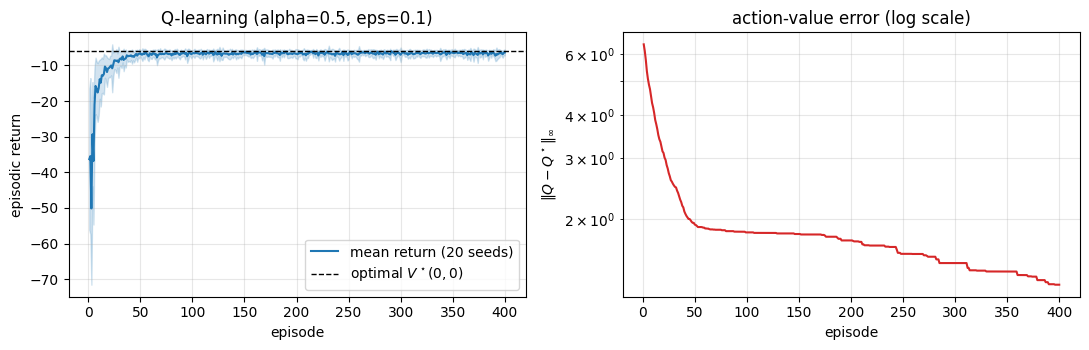

In [4]:

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ep = np.arange(1, n_ep+1)
ax[0].plot(ep, mean_ret, lw=1.5, color='C0', label='mean return (20 seeds)')
ax[0].fill_between(ep, mean_ret-std_ret, mean_ret+std_ret, color='C0', alpha=0.2)
ax[0].axhline(Q_star[0].max(), ls='--', c='k', lw=1, label=r'optimal $V^\star(0,0)$')
ax[0].set(xlabel='episode', ylabel='episodic return',
          title=f'Q-learning (alpha={alpha0}, eps={eps0})')
ax[0].legend(loc='lower right'); ax[0].grid(alpha=0.3)

ax[1].semilogy(ep, mean_err, lw=1.5, color='C3')
ax[1].set(xlabel='episode', ylabel=r'$\Vert Q - Q^\star\Vert_\infty$',
          title='action-value error (log scale)')
ax[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()


In [5]:

alphas = [0.05, 0.1, 0.3, 0.5, 0.8]
epss   = [0.01, 0.05, 0.1, 0.3, 0.5]
grid = np.zeros((len(alphas), len(epss)))
for i, a in enumerate(alphas):
    for j, e in enumerate(epss):
        rs = np.zeros(8)
        for s in range(8):
            _, r, _ = q_learn(a, e, n_episodes=300, seed=2000+s)
            rs[s] = r[-50:].mean()
        grid[i, j] = rs.mean()

heat = pd.DataFrame(grid.round(2),
                    index=[f"a={a}" for a in alphas],
                    columns=[f"eps={e}" for e in epss])
heat


,eps=0.01,eps=0.05,eps=0.1,eps=0.3,eps=0.5
a=0.05,-8.020,-8.120,-8.290,-9.170,-11.560
a=0.1,-6.340,-6.540,-6.840,-8.260,-11.330
a=0.3,-6.040,-6.250,-6.570,-8.070,-11.080
a=0.5,-6.060,-6.270,-6.640,-8.260,-10.960
a=0.8,-6.090,-6.270,-6.660,-8.340,-11.100


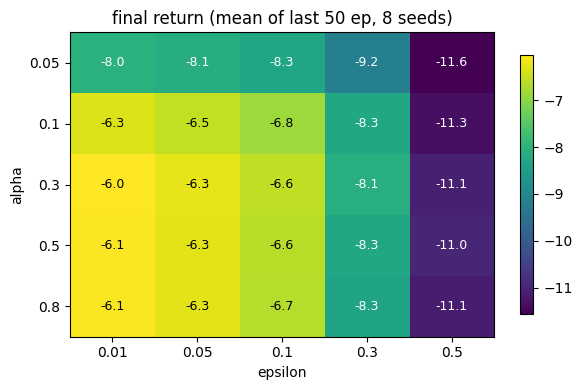

In [6]:

fig, ax = plt.subplots(figsize=(6.2, 4))
im = ax.imshow(grid, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(epss)),   [str(e) for e in epss])
ax.set_yticks(range(len(alphas)), [str(a) for a in alphas])
ax.set_xlabel('epsilon'); ax.set_ylabel('alpha')
ax.set_title('final return (mean of last 50 ep, 8 seeds)')
for i in range(len(alphas)):
    for j in range(len(epss)):
        ax.text(j, i, f"{grid[i,j]:.1f}", ha='center', va='center',
                color='w' if grid[i,j] < grid.mean() else 'k', fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.85); plt.tight_layout(); plt.show()


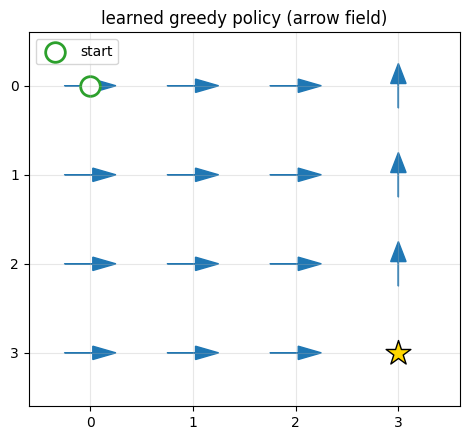

greedy action from (0,0): 1


In [7]:

Q_final, _, _ = q_learn(alpha=0.5, eps=0.1, n_episodes=600, seed=0)
greedy = Q_final.argmax(axis=1)
ARR = {0:(0,-1), 1:(1,0), 2:(0,1), 3:(-1,0)}

fig, ax = plt.subplots(figsize=(4.8, 4.5))
for i in range(NS):
    r, c = idx_s(i)
    if (r, c) == GOAL:
        ax.scatter(c, N-1-r, s=350, marker='*', color='gold', edgecolor='k', zorder=3)
        continue
    a = greedy[i]
    dx, dy = ARR[a]
    ax.arrow(c-0.25*dx, (N-1-r)-0.25*dy, 0.5*dx, 0.5*dy,
             head_width=0.15, length_includes_head=True, color='C0')

ax.scatter(0, N-1, s=200, marker='o', facecolor='w', edgecolor='C2', lw=2, label='start')
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(range(N)); ax.set_yticklabels(range(N-1, -1, -1))
ax.set_xlim(-0.6, N-0.4); ax.set_ylim(-0.6, N-0.4); ax.grid(True, alpha=0.3)
ax.set_title('learned greedy policy (arrow field)')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
print("greedy action from (0,0):", greedy[0])


## 4. 결과 해석

1. **학습곡선** — 리턴이 초기 큰 음수에서 100 에피소드 안에 최적치 부근으로 수렴. 최적 리턴은 $V^\star(0,0)\approx -5.85$ 이며 ε-greedy 로 가끔 잘못된 액션이 섞여 평균은 이보다 살짝 낮은 값에 안착한다.
2. **$\|Q-Q^\star\|_\infty$ 로그 스케일** — 지수적으로 감쇠하다가 상수 스텝사이즈의 잡음 볼 $O(\alpha)$ 에서 수평화. Robbins–Monro 이론이 예측하는 거동.
3. **$(\alpha,\varepsilon)$ 히트맵** — 스윗스팟은 $\alpha\in[0.3,0.5]$, $\varepsilon\in[0.05,0.1]$. $\varepsilon$ 이 크면 탐색 비용으로 리턴 하락, $\alpha$ 가 너무 작으면 학습이 늦고 너무 크면 잡음이 커진다.
4. **화살표 필드** — 학습된 정책은 시작 $(0,0)$ → 목표 $(3,3)$ 의 오른쪽/아래 최단경로.

> **결론**: 결정적 tabular 세팅에서 Q-learning 은 몇 백 에피소드로 최적 정책을 복원한다. 문제가 커질 때 나타나는 세 가지 병리 — 방문 밀도 편중, $\max$ 편향, 파라미터 갱신의 시간 상관 — 가 다음 두 문제의 동기이다.